In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram

# Distribution embedding

{'0000': 2, '0001': 0, '0010': 5, '0011': 15, '0100': 32, '0101': 88, '0110': 105, '0111': 161, '1000': 152, '1001': 174, '1010': 107, '1011': 90, '1100': 53, '1101': 25, '1110': 9, '1111': 5}


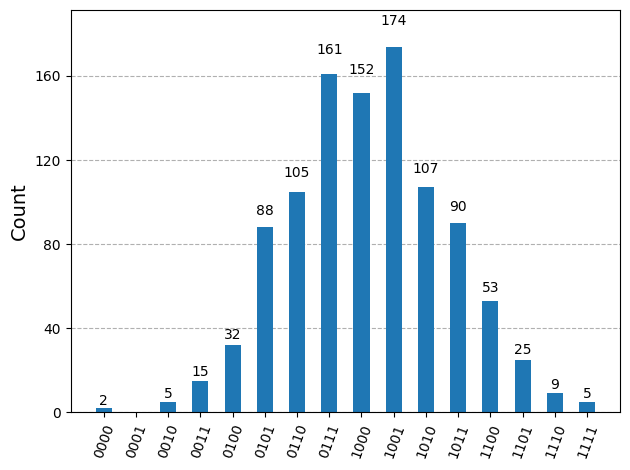

In [2]:
from distributions import MinMaxBinning, SingleGaussian
num_qubits = 4
nbins = 2**num_qubits

def sample_dist(_size, _nbins):
    _sample = SingleGaussian(shots = _size)
    return MinMaxBinning(_sample, _nbins)

sample = sample_dist(2**10, nbins)
print(sample)
plot_histogram(sample)

# QGAN evaluation

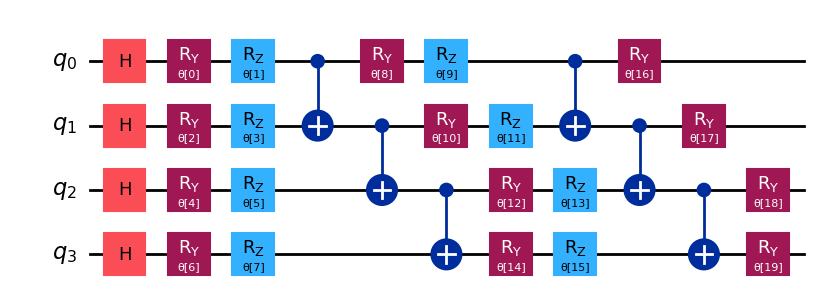

In [3]:
from qiskit.circuit import ParameterVector

reps = 2
qc = QuantumCircuit(num_qubits)
qc.h(range(num_qubits))
theta = ParameterVector("θ", length=(reps + 1) * num_qubits * 2)

p = 0
for r in range(reps + 1):
    for q in range(num_qubits):
        qc.ry(theta[p], q)
        p += 1

        if r < reps:
            qc.rz(theta[p], q)
            p += 1
        
    if r < reps:
        for q in range(num_qubits - 1):
            qc.cx(q, q + 1)

qc.draw("mpl")


In [4]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, InputLayer


discriminator = Sequential([InputLayer(shape=(nbins,)),
                            Dense(32, activation='tanh'),
                            Dense(64, activation='tanh'),
                            Dense(32, activation='tanh'),
                            Dense(1, activation='sigmoid')
                            ])
discriminator.summary()

2026-03-10 12:36:12.980960: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 12:36:13.001709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773142573.022601  171583 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773142573.028794  171583 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773142573.046074  171583 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,769 (18.63 KB)

 Trainable params: 4,769 (18.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from qgan import QGAN
model = QGAN(num_qubits = int(np.log2(nbins)),
             generator = qc,
             discriminator = discriminator,
             real_dist = sample_dist)

In [6]:
epochs = 2000
model.fit(epochs = epochs, shots = 2**11, manager = True, opt = 'ADAM_PSR', lr = 1e-3)

Monitoring run: run_20260310_123616
Training started


100%|██████████| 2000/2000 [1:08:06<00:00,  2.04s/it]  

Training completed


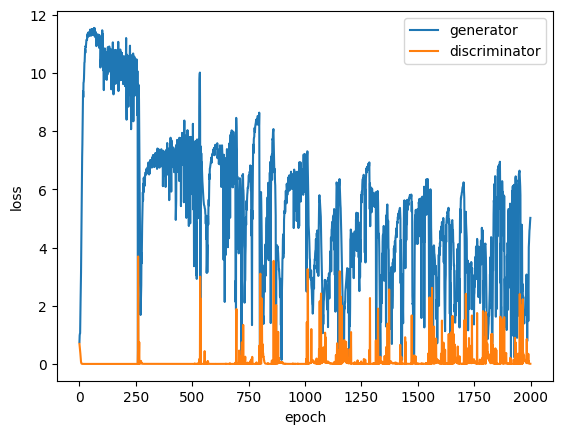

In [7]:
plt.plot(model.generator_losses, label = 'generator')
plt.plot(model.discriminator_losses, label = 'discriminator')
plt.legend()
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

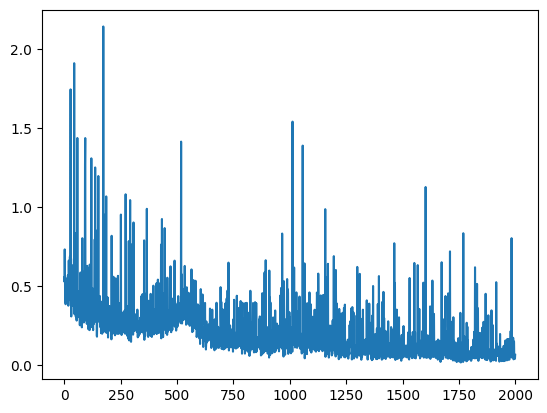

In [8]:
plt.plot(model.metrics['kullback_leibler'])

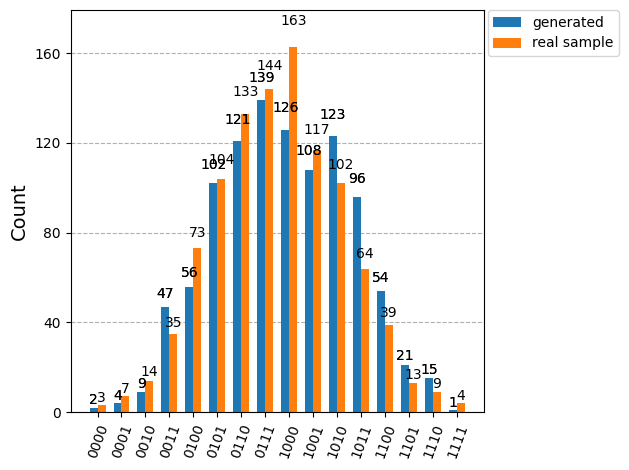

In [14]:
nsamples = 2**10
gen_res = model.get_sample(nsamples)
real_res = sample_dist(nsamples, nbins)
plot_histogram([gen_res, real_res], legend = ["generated","real sample"])